In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset

# data load and EDA

In [3]:
data = pd.read_csv("online_shoppers.csv")
data.head()

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,S-100000,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,S-100001,0,0.0,0,0.0,2.0,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,S-100002,0,0.0,0,NaN,1.0,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,S-100003,0,0.0,0,NaN,2.0,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,S-100004,0,0.0,0,NaN,10.0,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,NaN,True,False


In [4]:
columns = data.select_dtypes(include="number").columns

columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='str')

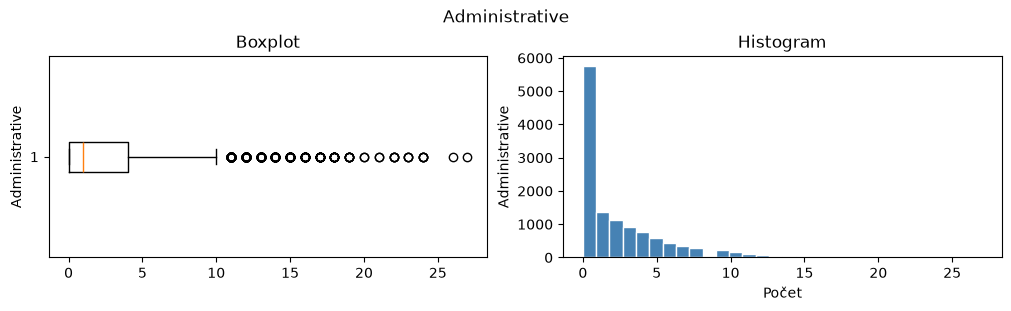

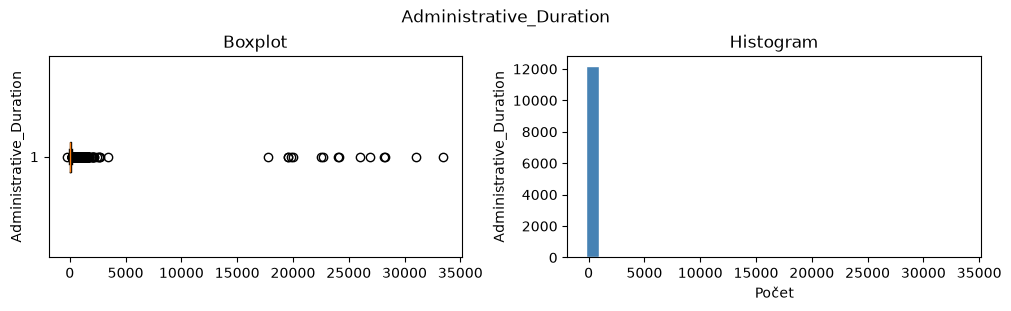

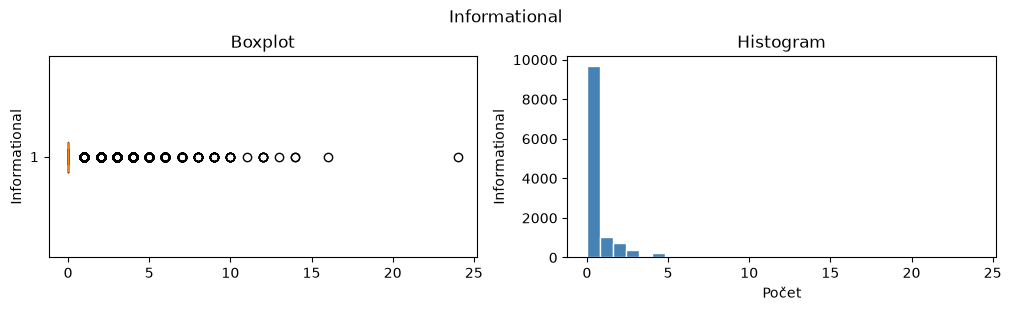

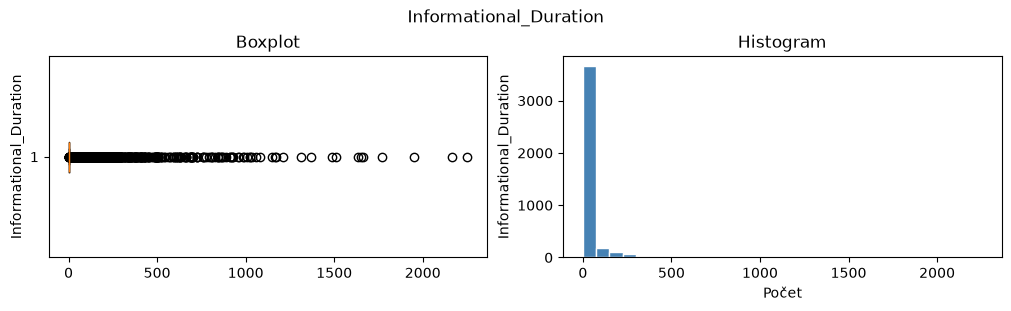

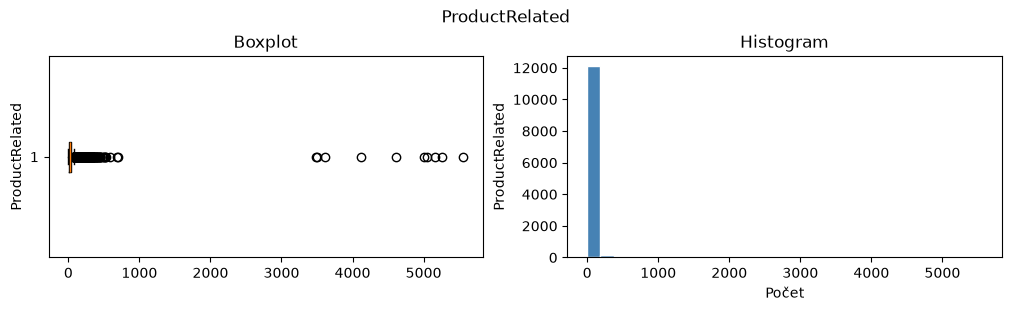

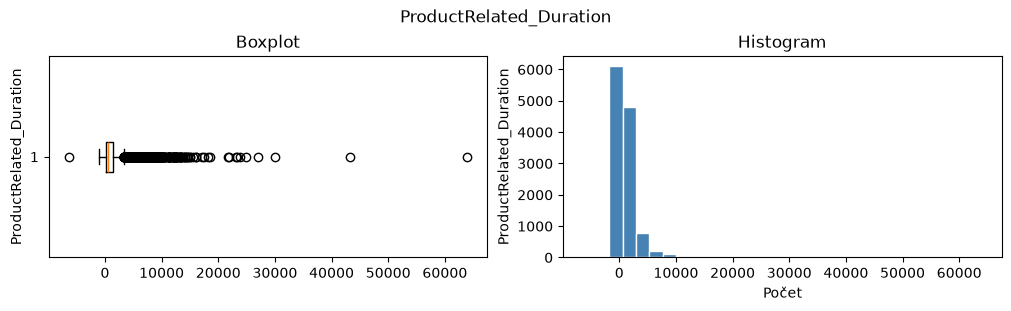

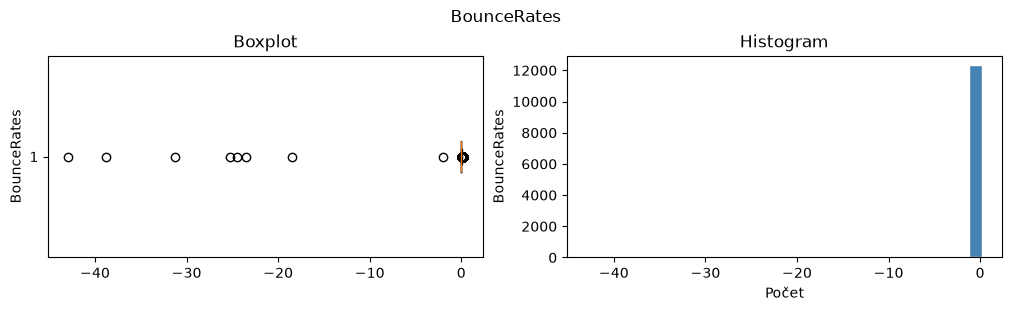

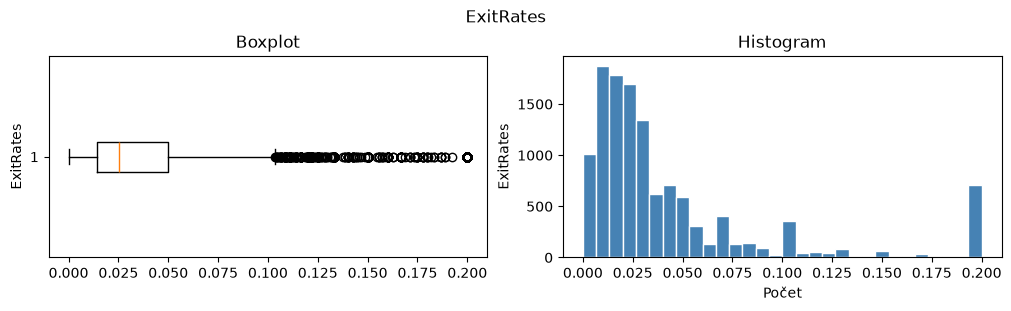

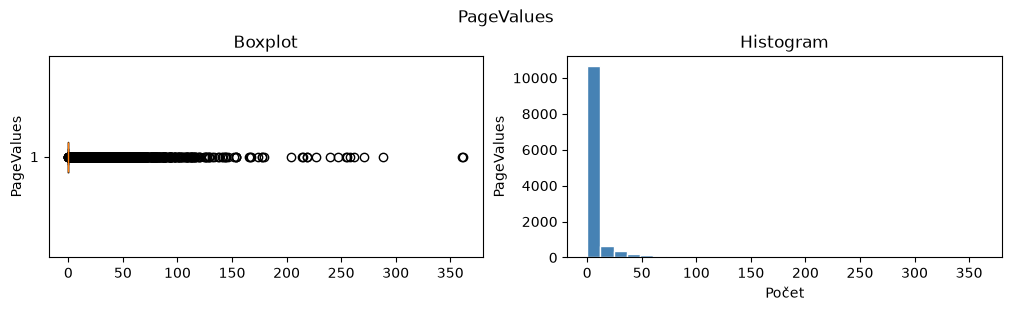

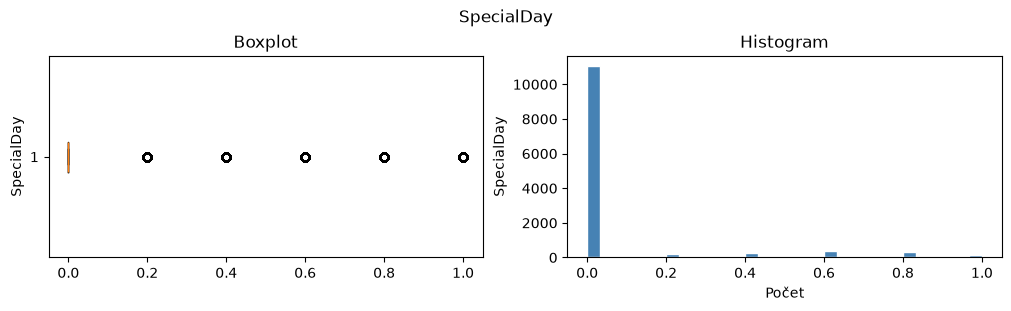

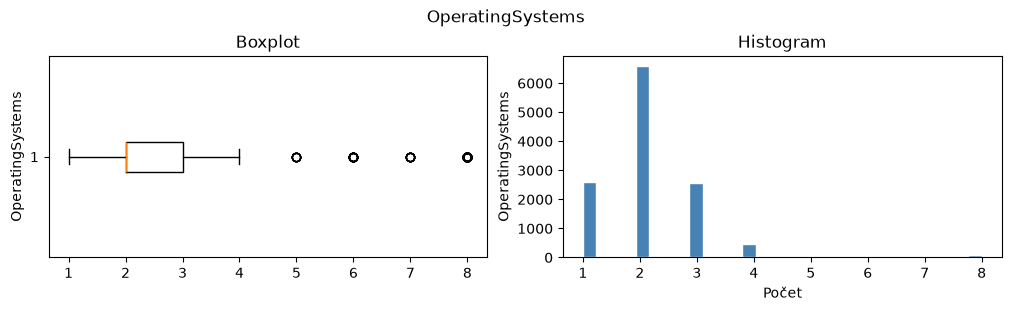

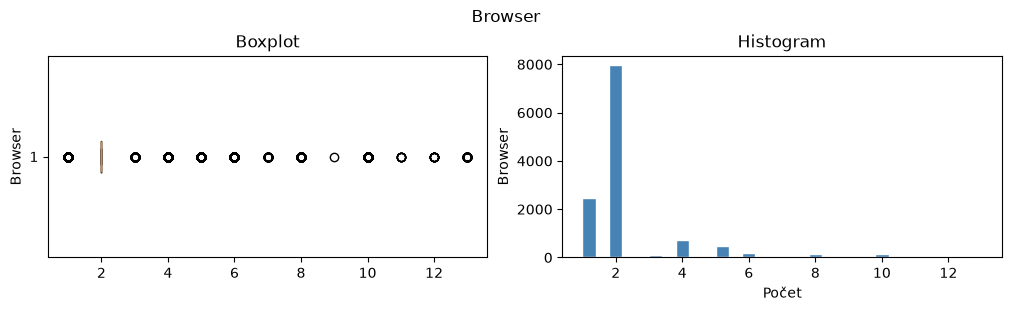

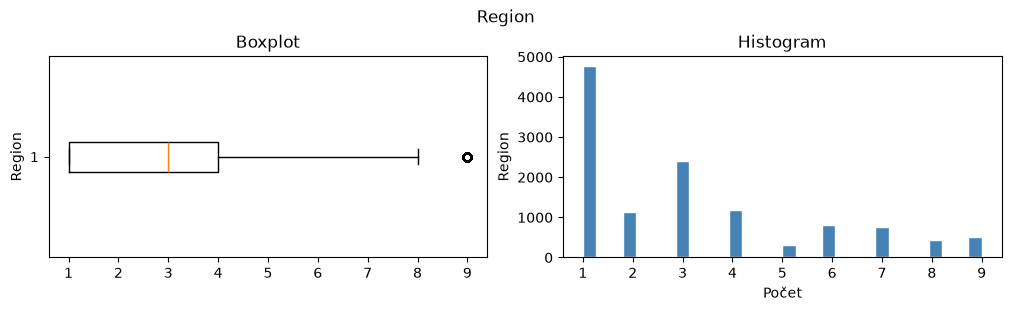

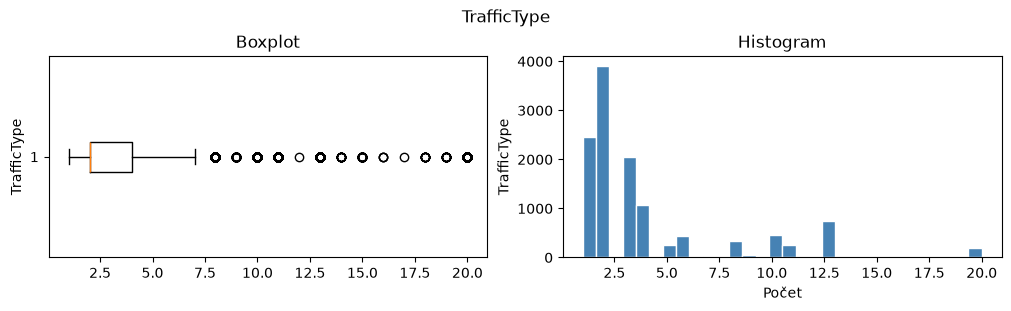

In [5]:
for column in columns:
    values = data[column].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(10, 3), constrained_layout=True)
    axes[0].boxplot(values, orientation="horizontal")
    axes[0].set(title="Boxplot", ylabel=column)
    axes[1].hist(values, bins=30, color="steelblue", edgecolor="white")
    axes[1].set(title="Histogram", xlabel="Počet", ylabel=column)
    fig.suptitle(column)
    plt.show()

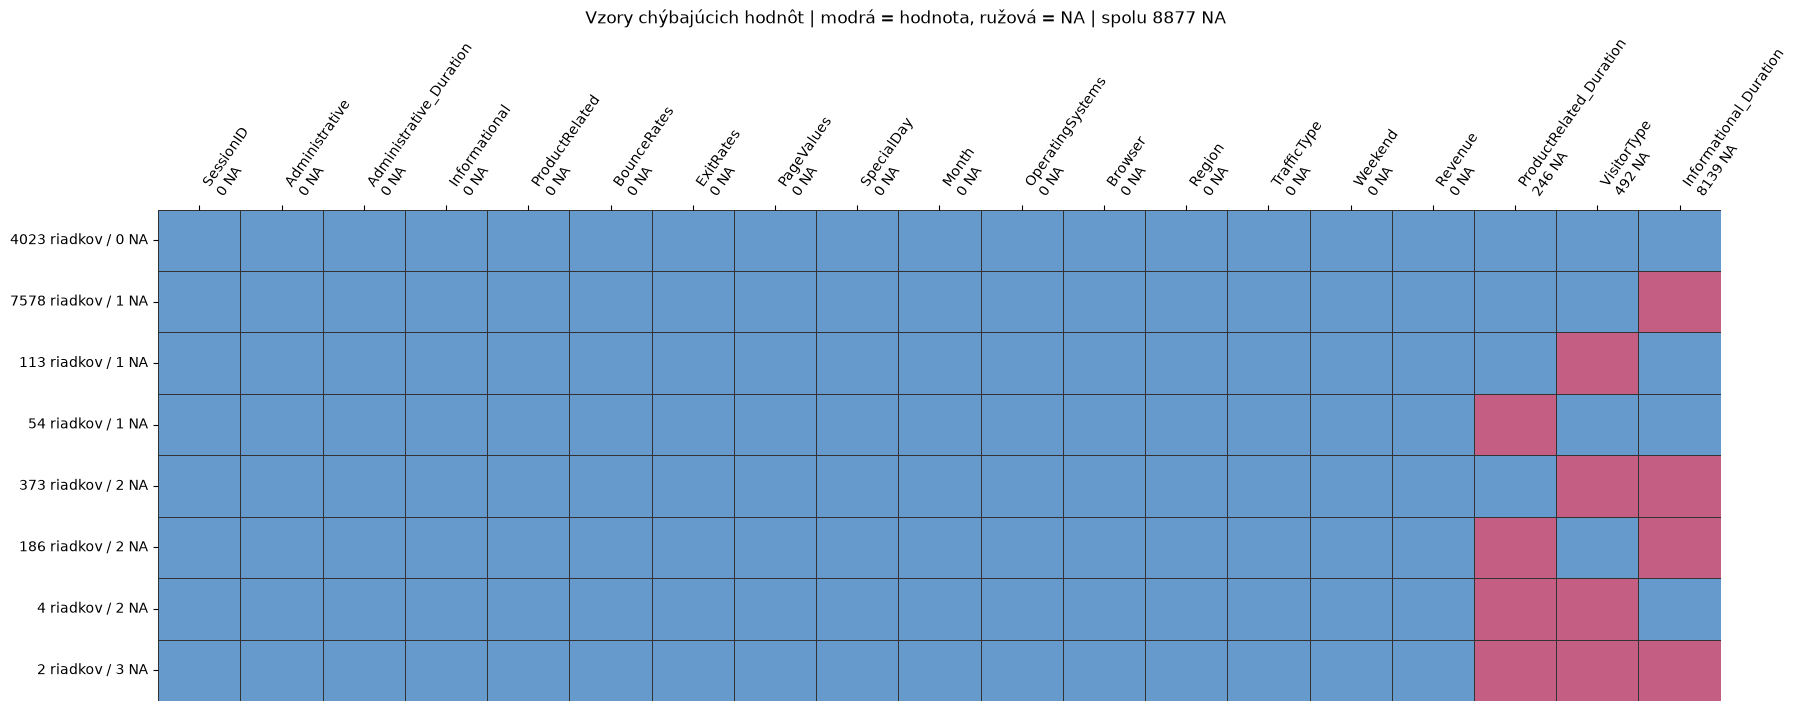

In [6]:
missing = data.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

- v cca 2/3 (8139/12334) dat chyba hodnota (NA) v poslednom stlpci Informational_Duration, co neni ani vhodne doplnat/nahradzat, preto tento stlpec je jednoduchsie a lepsie dropnut
- taktiez mozme dropnut indexy (rows) riadky, ktore su na grafe zobrazene ako posledne 2 kde chyba v 2 riadkoch 3 hodnoty a v 4 riadkoch 2 hodnoty

In [7]:
# dropnutie stlpca a riadkov
rows_to_drop = data["ProductRelated_Duration"].isna() | data["VisitorType"].isna()
data_clean = data.drop(index=data.index[rows_to_drop], columns="Informational_Duration").copy()

In [8]:
data_clean.describe()

,Administrative,Administrative_Duration,Informational,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000,11601.000000
mean,2.326437,112.502691,0.507801,35.006637,1199.481299,0.004117,0.042697,6.154971,0.061546,2.122662,2.351608,3.140160,4.077752
std,3.327508,901.008974,1.270743,127.664326,1918.490414,0.748188,0.048397,19.006150,0.199062,0.910592,1.708669,2.394896,4.027833
min,0.000000,-214.548633,0.000000,0.000000,-6423.973010,-42.953427,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,7.000000,185.000000,0.000000,0.014251,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,8.000000,0.000000,18.000000,604.000000,0.003014,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.600000,0.000000,38.000000,1467.654221,0.016667,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,33466.707646,24.000000,5258.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


### removing outliers

In [9]:
def remove_outliers(df):
    counts = ["Administrative", "Informational", "ProductRelated"]
    nonnegative = counts + [
        "Administrative_Duration",
        "Informational_Duration",
        "ProductRelated_Duration",
        "PageValues",
    ]

    bounds = {column: (0, np.inf) for column in nonnegative}
    bounds.update({
        "BounceRates": (0, 1),
        "ExitRates": (0, 1),
        "SpecialDay": (0, 1),
    })

    categories = {
        "OperatingSystems": range(1, 9),
        "Browser": range(1, 14),
        "Region": range(1, 10),
        "TrafficType": range(1, 21),
        "Month": ["Feb", "Mar", "May", "June", "Jul",
                  "Aug", "Sep", "Oct", "Nov", "Dec"],
        "VisitorType": ["Returning_Visitor", "New_Visitor", "Other"],
        "Weekend": [True, False],
        "Revenue": [True, False],
    }

    valid = pd.Series(True, index=df.index)

    for column, (lower, upper) in bounds.items():
        if column not in df.columns:
            continue

        values = df[column]
        valid &= values.isna() | (
            values.between(lower, upper) & np.isfinite(values)
        )

        if column in counts:
            valid &= values.isna() | values.mod(1).eq(0)

    for column, allowed in categories.items():
        values = df[column]
        valid &= values.isna() | values.isin(allowed)

    return df.loc[valid].copy()

In [10]:
before = len(data_clean)
data_clean = remove_outliers(data_clean)

before, len(data_clean)

(11601, 11583)

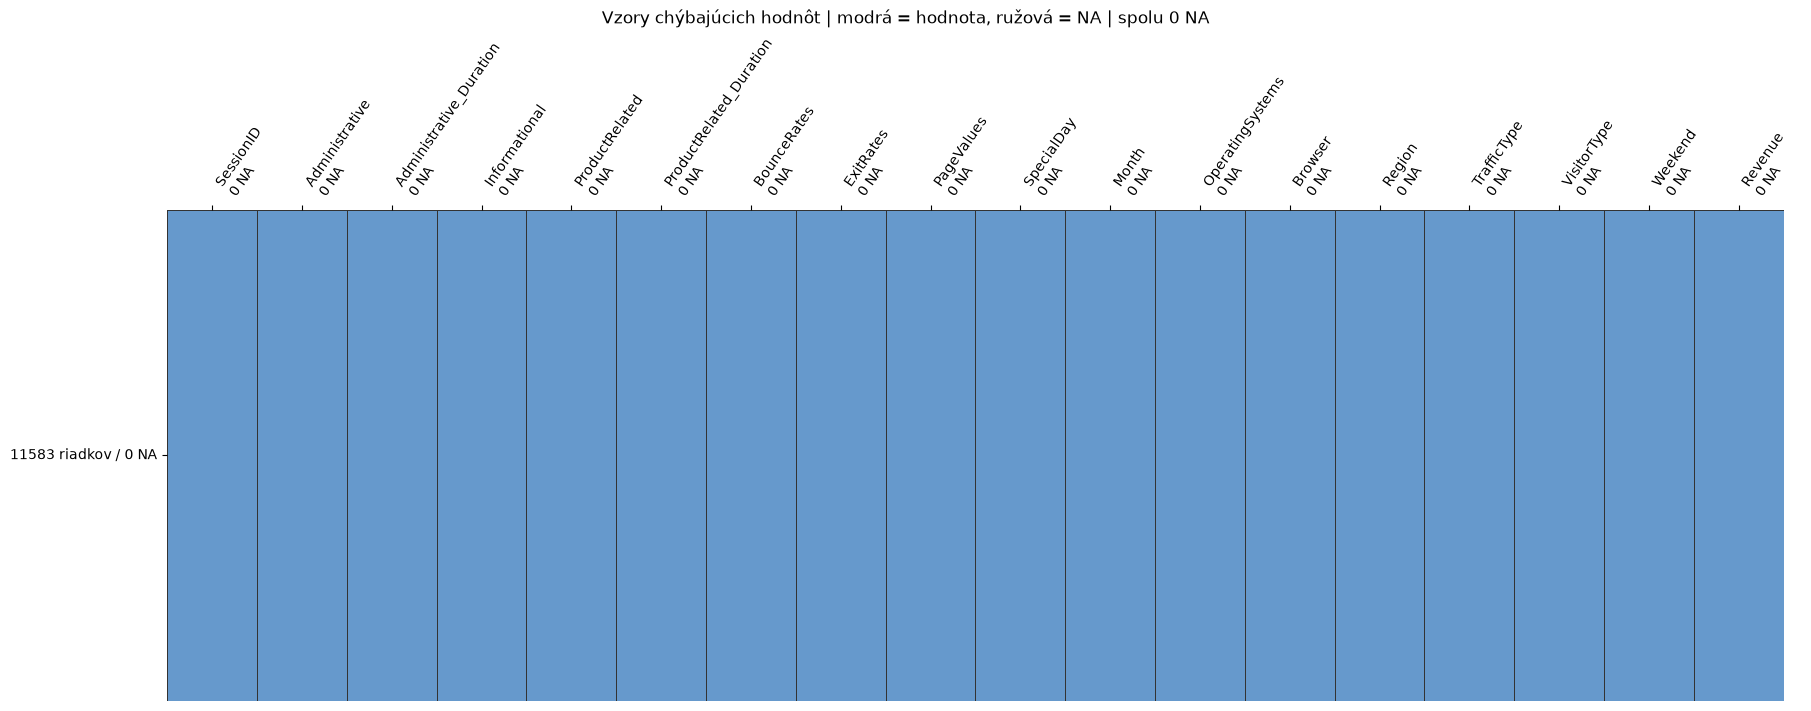

In [11]:
missing = data_clean.isna()
ordered_cols = missing.sum().sort_values(kind="stable").index
patterns = missing.value_counts().rename("rows").reset_index()
patterns["na"] = patterns[data_clean.columns].sum(axis=1)
patterns = patterns.sort_values(["na", "rows"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(18, 7), constrained_layout=True)
sns.heatmap(patterns[ordered_cols].astype(int), cmap=["#6699cc", "#c45f83"],
            vmin=0, vmax=1, cbar=False, linewidths=0.5, linecolor="#333", ax=ax)
ax.set_xticklabels([f"{col}\n{missing[col].sum()} NA" for col in ordered_cols], rotation=55, ha="left")
ax.set_yticklabels([f"{rows} riadkov / {na} NA" for rows, na in zip(patterns["rows"], patterns["na"])], rotation=0)
ax.tick_params(axis="x", top=True, labeltop=True, bottom=False, labelbottom=False)
fig.suptitle(f"Vzory chýbajúcich hodnôt | modrá = hodnota, ružová = NA | spolu {missing.sum().sum()} NA")
plt.show()

## VisitorType vs ProductRelated a PageValues

In [12]:
visitor_types = ["Returning_Visitor", "New_Visitor", "Other"]
visitor_data = data_clean[data_clean["VisitorType"].isin(visitor_types)].copy()
for metric in ["PageValues", "ProductRelated"]:
    visitor_data[f"log1p_{metric}"] = np.log1p(visitor_data[metric])

visitor_data["VisitorType"].value_counts().reindex(visitor_types)

VisitorType
Returning_Visitor    9912
New_Visitor          1593
Other                  78
Name: count, dtype: int64

pouzity $\log{(1 + x)}$ (log1p), kvoli normalizacii velmi odlahlych hodnot a obsahovani 0 hodnot, logaritmus 1+x zachova 0 na 0, normalizacia zachovana aj kvoli porovnaniu roznych skupin

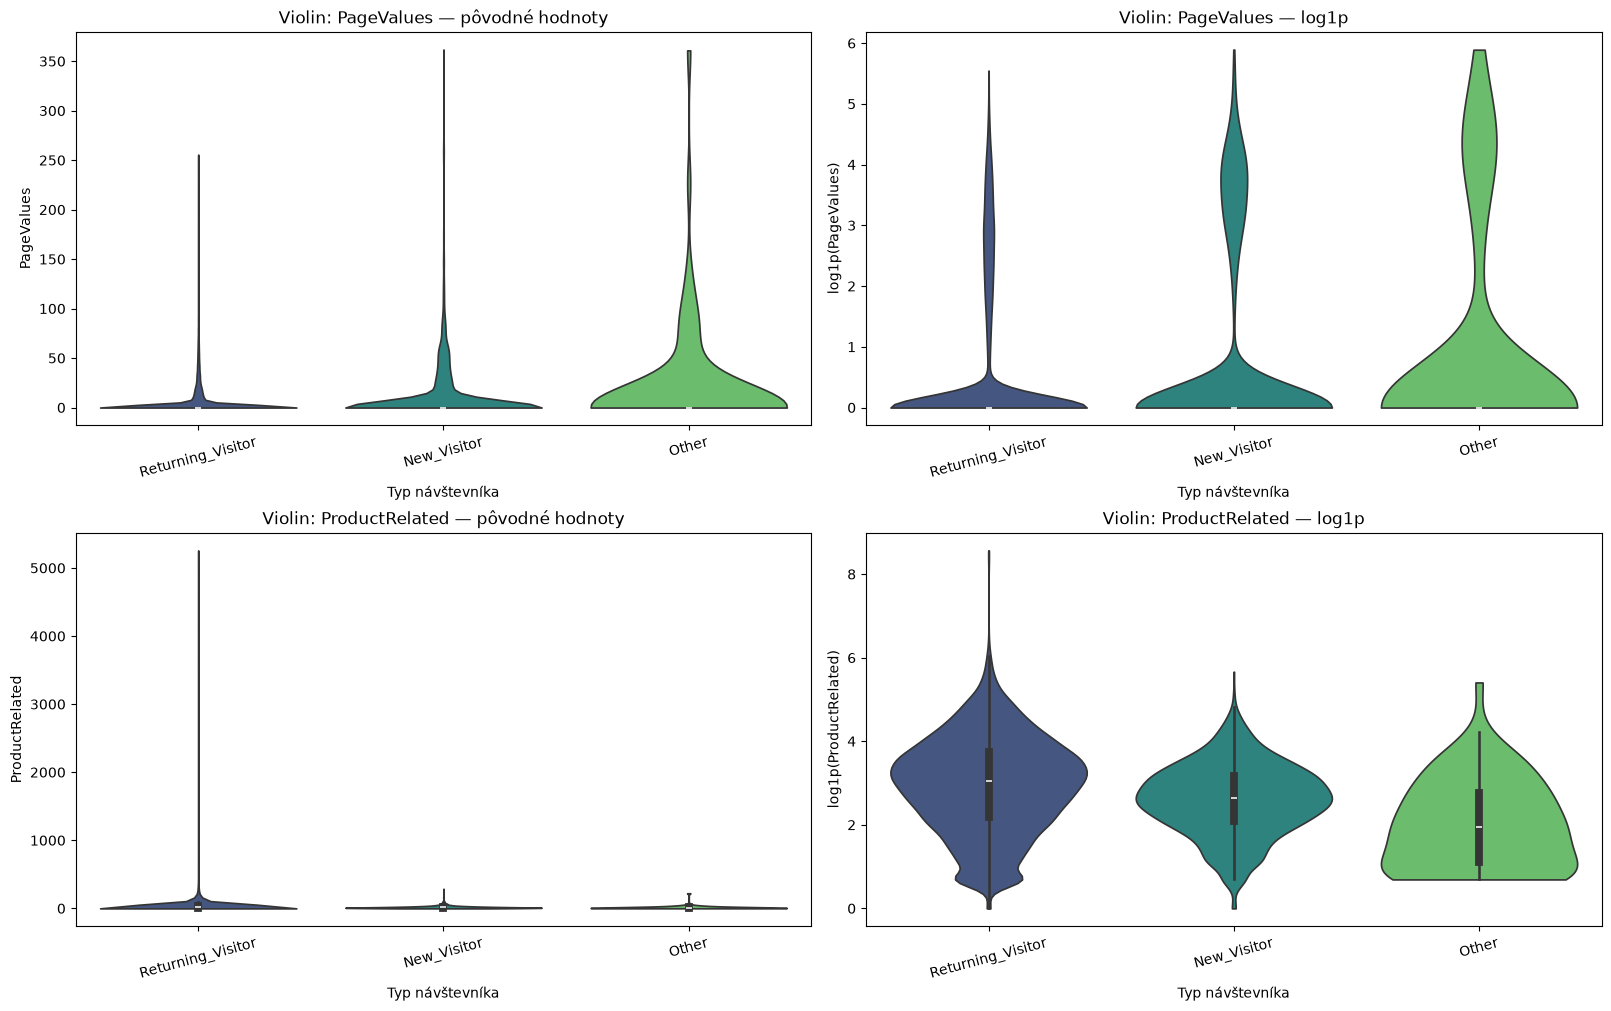

In [13]:
visitor_palette = dict(zip(visitor_types, sns.color_palette("viridis", len(visitor_types))))

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.violinplot(
            data=visitor_data, x="VisitorType", y=value_column,
            order=visitor_types, hue="VisitorType", hue_order=visitor_types,
            palette=visitor_palette, dodge=False, legend=False,
            inner="box", cut=0,
            ax=ax,
        )
        ax.set(title=f"Violin: {metric} — {variant_label}",
               xlabel="Typ návštevníka", ylabel=value_label)
        ax.tick_params(axis="x", rotation=15)

plt.show()


Pri PageValues sa vo vsetkych skupinach vacsina hodnot sustreduje pri nule. Rozdelenia maju dlhe chvosty, kde sa tahaju k vysokym hodnotam. Transformacia $log1p$ zlepsuje zobrazenie hodnot, kde je vidno ze v skupine Other je hustota posunuta k vyssim hodnotam nez pri vracajucich sa navstevnikov.

Pri ProductRelated povodnu mierku vyrazne ovplyvnuju extremne hodnoty vracajucich sa navstevnikov. Po transformacii su rozdiely citatelnejsie, kde vracajuci sa navstevnivi maju najvyssi median a najnizsi ostatny typ navstevnikov. Vracajuci navstevnici navstevuju viac produktovo suvisiacich stranok.

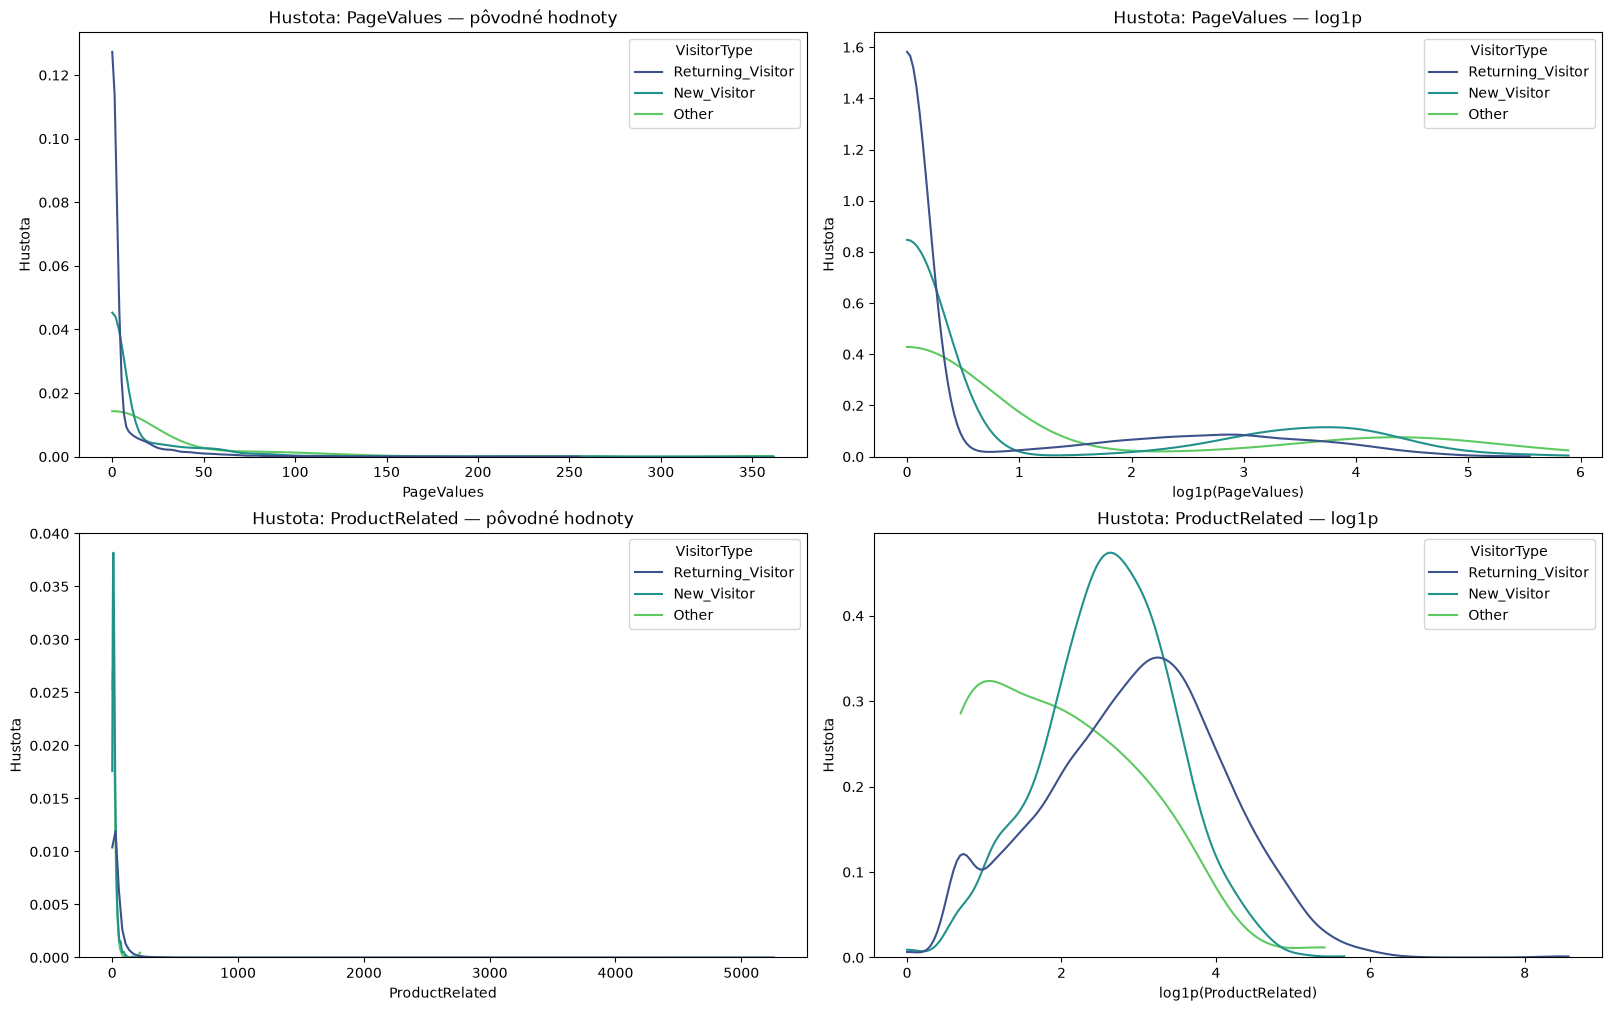

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for row, metric in enumerate(["PageValues", "ProductRelated"]):
    for col, variant in enumerate(["original", "log1p"]):
        value_column = metric if variant == "original" else f"log1p_{metric}"
        value_label = metric if variant == "original" else f"log1p({metric})"
        variant_label = "pôvodné hodnoty" if variant == "original" else "log1p"
        ax = axes[row, col]
        sns.kdeplot(
            data=visitor_data, x=value_column, hue="VisitorType",
            hue_order=visitor_types, palette=visitor_palette,
            common_norm=False,
            cut=0,
            ax=ax,
        )
        ax.set(title=f"Hustota: {metric} — {variant_label}",
               xlabel=value_label, ylabel="Hustota")

plt.show()


Pri PageValues vidime vyrazny vrchol pri nule a dlhy chvost pri vsetkych skupinach. Pri nule je najhustejsia skupina vracajucich sa zakaznikov, pri skupinach New_Visitor a Other su hodnoty sirsie.

Pri ProductRelated je najvyssia hodnota v skupine novych zakaznikov v oblasti medzi 2 a 4 (os logaritmu skupiny). Skupina Other ma najhustejsiu hodnotu blizsie k nule a vracajuci sa zakaznici maju najhustejsiu hodnotu vo vyssich hodnotach.

## Month (mesiac poslednej navstevy) a Revenue

Porovnavam podiel sessionov ukoncenych nakupom v jednolivych mesiacoch. Pocet nakupov / pocet sessions v danom mesiaci. Mesacne podiely a chybove usecky, v ich 95% Wilson intervaloch spolahlivosti, co vyjadruje neistotu odhadu pri predpoklade nezavislych sessionov. V datasete chybaju data za mesiac januar a april.

Boxplot sumarizuje rozdelenie mesacnych podielov. 

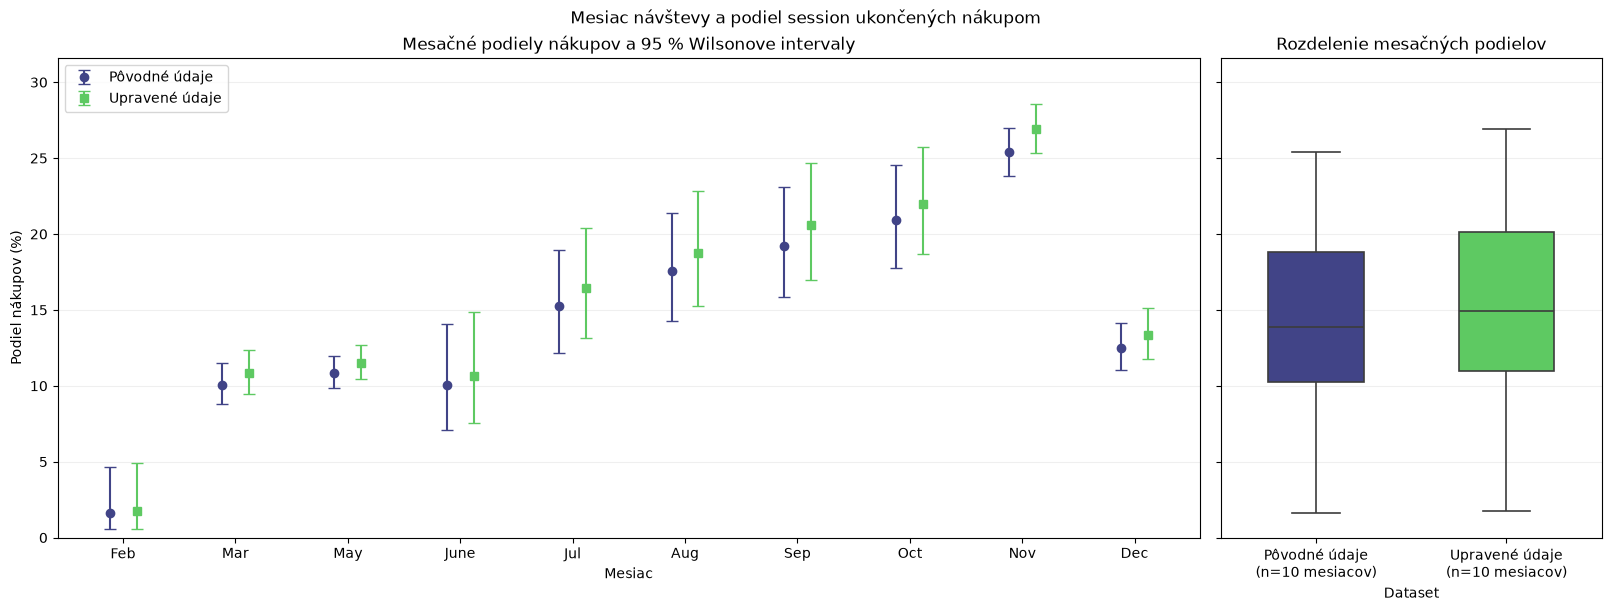

Pôvodné údaje                                           Upravené údaje  \
           sessions purchases purchase_rate ci_lower ci_upper       sessions   
Month                                                                          
Feb             185         3          1.62     0.55     4.66            174   
Mar            1907       192         10.07     8.80    11.50           1775   
May            3365       365         10.85     9.84    11.94           3171   
June            288        29         10.07     7.10    14.09            272   
Jul             432        66         15.28    12.19    18.98            401   
Aug             433        76         17.55    14.26    21.42            405   
Sep             448        86         19.20    15.82    23.10            418   
Oct             549       115         20.95    17.75    24.55            523   
Nov            2999       761         25.38    23.85    26.96           2826   
Dec            1727       216         12.51    11.03    14.15           1618   

                                                 
      purchases purchase_rate ci_lower ci_upper  
Month                                            
Feb           3          1.72     0.59     4.95  
Mar         192         10.82     9.46    12.35  
May         365         11.51    10.45    12.67  
June         29         10.66     7.53    14.89  
Jul          66         16.46    13.15    20.40  
Aug          76         18.77    15.26    22.85  
Sep          86         20.57    16.98    24.71  
Oct         115         21.99    18.65    25.74  
Nov         761         26.93    25.33    28.59  
Dec         216         13.35    11.78    15.09

In [15]:
month_order = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
datasets = {"Pôvodné údaje": data, "Upravené údaje": data_clean}
month_summary = {}
colors = plt.get_cmap("viridis")([0.2, 0.75])
positions = np.arange(len(month_order))
z = 1.959963984540054

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), sharey=True,
    gridspec_kw={"width_ratios": [3, 1]}, constrained_layout=True
)

for i, (label, frame) in enumerate(datasets.items()):
    monthly = (
        frame.dropna(subset=["Month", "Revenue"])
        .groupby("Month")["Revenue"]
        .agg(sessions="size", purchases="sum", purchase_rate="mean")
        .reindex(month_order)
    )
    sessions = monthly["sessions"]
    proportion = monthly["purchase_rate"]
    denominator = 1 + z**2 / sessions
    center = (proportion + z**2 / (2 * sessions)) / denominator
    half_width = (
        z * np.sqrt(
            proportion * (1 - proportion) / sessions
            + z**2 / (4 * sessions**2)
        ) / denominator
    )
    monthly["purchase_rate"] *= 100
    monthly["ci_lower"] = (center - half_width).clip(0, 1) * 100
    monthly["ci_upper"] = (center + half_width).clip(0, 1) * 100
    month_summary[label] = monthly

    rate = monthly["purchase_rate"]
    axes[0].errorbar(
        positions + (i - 0.5) * 0.24,
        rate,
        yerr=np.maximum(np.vstack([
            rate - monthly["ci_lower"], monthly["ci_upper"] - rate
        ]), 0),
        fmt=["o", "s"][i],
        linestyle="none",
        color=colors[i],
        capsize=4,
        markersize=6,
        label=label,
    )

axes[0].set(
    title="Mesačné podiely nákupov a 95 % Wilsonove intervaly",
    xlabel="Mesiac",
    ylabel="Podiel nákupov (%)",
    xticks=positions,
    xticklabels=month_order,
    ylim=(0, max(table["ci_upper"].max() for table in month_summary.values()) + 3),
)
axes[0].legend()

monthly_rates = pd.DataFrame({
    label: table["purchase_rate"] for label, table in month_summary.items()
})
sns.boxplot(
    data=monthly_rates, palette=list(colors), saturation=1,
    width=0.5, linewidth=1.2, ax=axes[1],
)
axes[1].set(title="Rozdelenie mesačných podielov", xlabel="Dataset", ylabel="")
axes[1].set_xticks(
    np.arange(len(datasets)),
    labels=[
        f"{label}\n(n={monthly_rates[label].count()} mesiacov)"
        for label in datasets
    ],
)
for axis in axes:
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)

fig.suptitle("Mesiac návštevy a podiel session ukončených nákupom")
plt.show()

pd.concat(month_summary, axis=1).round(2)


Najvyssi podiel nakupov je za mesiac november, priblizne 25.4% v neupravenych a v upravenych 26.9% datach. Najnizsie je za mesiac februar, kde dosahuje podiel iba 1.6% a 1.7%.

Intervaly spolahlivosti spresnuju informaciu o presnosti odhadov, kde zavisi od poctu sessions aj od podielu nakupov. Maj ma uzsi interval ako mesiac august, ktory obsahuje menej sessionov.

Pri cisteni boli odstranene iba sessiony bez nakupu, pocet nakupov preto ostal rovnaky, zatial co sessiony klesli, co zvysilo podiel nakupov v upravenych datach.

### Correlation of session and purchase by month

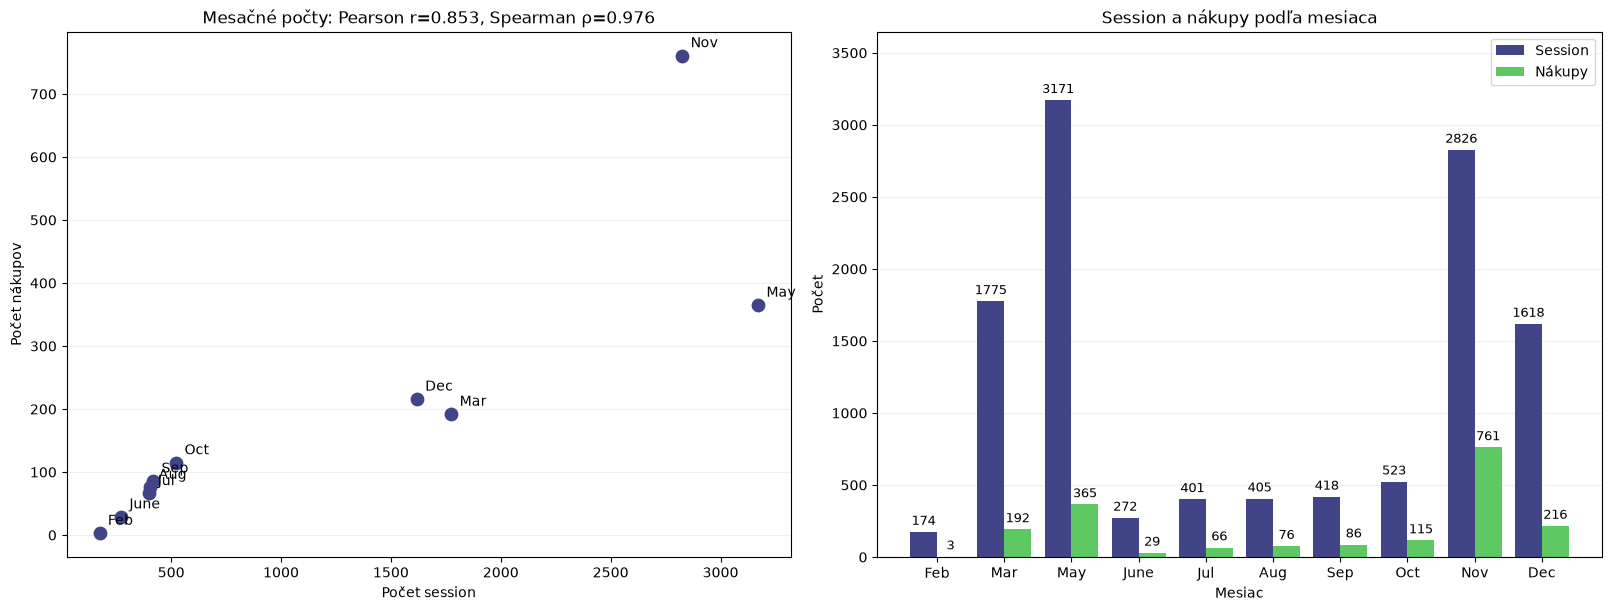

,Počet session,Počet nákupov,Podiel nákupov (%),Pearson,Spearman
Mesiac,,,,,
Feb,174,3,1.72,—,—
Mar,1775,192,10.82,—,—
May,3171,365,11.51,—,—
June,272,29,10.66,—,—
Jul,401,66,16.46,—,—
Aug,405,76,18.77,—,—
Sep,418,86,20.57,—,—
Oct,523,115,21.99,—,—
Nov,2826,761,26.93,—,—


In [20]:
# Použije mesačné počty vypočítané v month_summary.
monthly = month_summary["Upravené údaje"][["sessions", "purchases"]].dropna()

pearson = monthly["sessions"].corr(monthly["purchases"], method="pearson")
spearman = monthly["sessions"].corr(monthly["purchases"], method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# Korelačný graf – jeden bod predstavuje jeden mesiac.
axes[0].scatter(
    monthly["sessions"], monthly["purchases"], s=80, color=colors[0]
)

for month, row in monthly.iterrows():
    axes[0].annotate(
        month, (row["sessions"], row["purchases"]),
        xytext=(6, 6), textcoords="offset points"
    )

axes[0].set(
    title=f"Mesačné počty: Pearson r={pearson:.3f}, Spearman ρ={spearman:.3f}",
    xlabel="Počet session",
    ylabel="Počet nákupov"
)

# Stĺpcový graf.
x = np.arange(len(monthly))
for offset, column, label, color in [
    (-0.2, "sessions", "Session", colors[0]),
    (0.2, "purchases", "Nákupy", colors[1])
]:
    bars = axes[1].bar(
        x + offset, monthly[column], width=0.4, label=label, color=color
    )
    axes[1].bar_label(bars, padding=3, fontsize=9)

axes[1].set(
    title="Session a nákupy podľa mesiaca",
    xlabel="Mesiac", ylabel="Počet",
    xticks=x, xticklabels=monthly.index
)
axes[1].margins(y=0.15)
axes[1].legend()

for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

plt.show()

# V každom mesiaci je iba jeden pár počtov: korelácia je nedefinovaná.
# Posledný riadok obsahuje korelácie naprieč mesiacmi.
table = monthly.rename(columns={
    "sessions": "Počet session",
    "purchases": "Počet nákupov"
}).copy()

table.index.name = "Mesiac"
table["Podiel nákupov (%)"] = (
    table["Počet nákupov"] / table["Počet session"] * 100
)
table["Pearson"] = np.nan
table["Spearman"] = np.nan

table.loc["Spolu / priemerný podiel / korelácie medzi mesiacmi"] = [
    monthly["sessions"].sum(),
    monthly["purchases"].sum(),
    table["Podiel nákupov (%)"].mean(),
    pearson,
    spearman
]

display(table.style.format({
    "Počet session": "{:.0f}",
    "Počet nákupov": "{:.0f}",
    "Podiel nákupov (%)": "{:.2f}",
    "Pearson": "{:.3f}",
    "Spearman": "{:.3f}"
}, na_rep="—"))

Pearsonova korelacia r = 0.853 naznacuje silny linearny vztah. Spearmanova korelacia $\rho = 0.976$ ukazuje, ze mesiace s vyssou navstevnostou maju takmer vzdy aj vyssi pocet nakupov.

Maj mal najviac sessionov 3 171 ale nakupom skoncilo 365, podiel 11.5%. November mal menej sessionov 2 826 no najviac nakupov 756, co je aj najvyssi podiel nakupov 26.9%. Najnizsie podiel dosiahol za mesiac februar a to 1.7%.

## ProductRelated a ExitRates

Hexbin graf ukazuje pocet produktovych stranok oproti priemernej miere odchodu zo stranok navstyvenych v sessions. Pouzivam log1p, co zachova nuly a zlepsuje citatelnost velkho rozsahu. Farba vyjadruje pocet sessionov v hexagone.

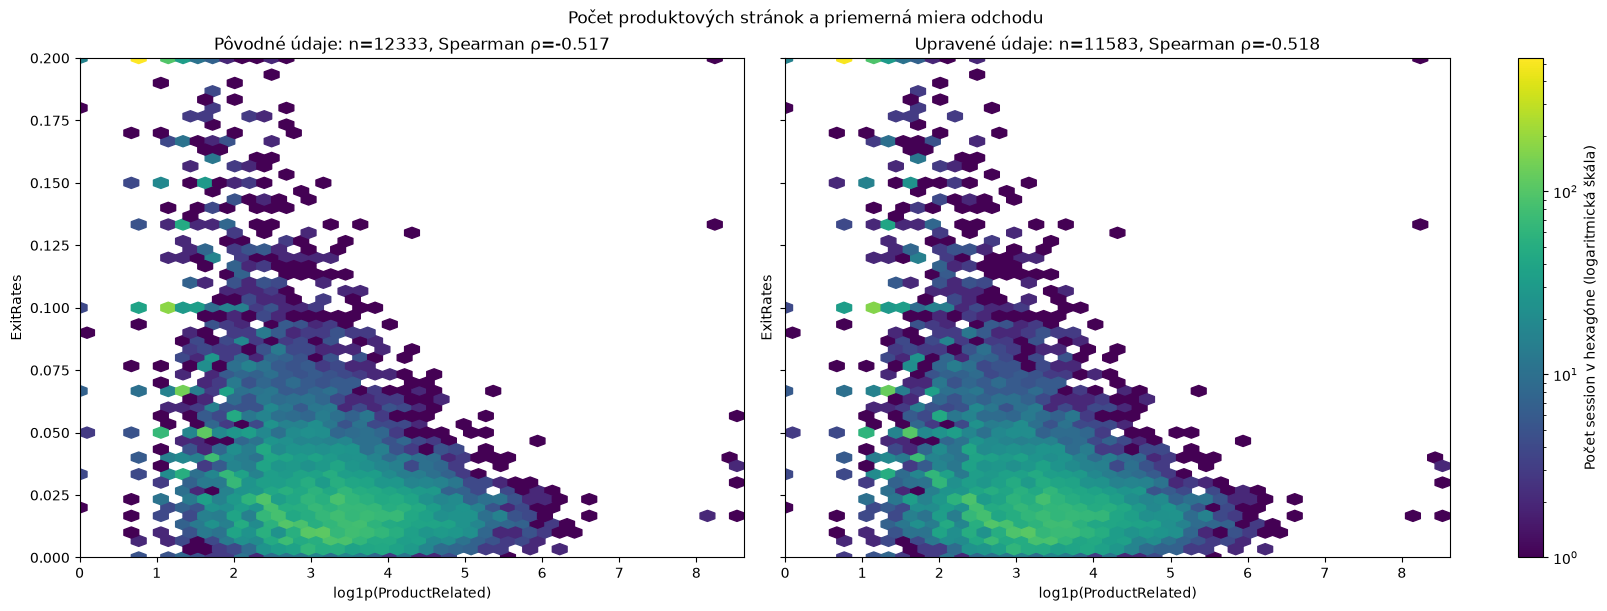

,Počet session,Spearman,Medián ExitRates (0–1 produktových stránok),Medián ExitRates (>50 produktových stránok)
Dataset,,,,
Pôvodné údaje,12333,-0.517,0.2,0.017
Upravené údaje,11583,-0.518,0.2,0.017


In [21]:
from matplotlib.colors import LogNorm

datasets = {"Pôvodné údaje": data, "Upravené údaje": data_clean}
exit_pairs = {
    label: frame[["ProductRelated", "ExitRates"]].dropna()
    for label, frame in datasets.items()
}
extent = (
    0,
    max(np.log1p(pair["ProductRelated"]).max() for pair in exit_pairs.values()),
    0,
    max(pair["ExitRates"].max() for pair in exit_pairs.values()),
)

fig, axes = plt.subplots(
    1, 2, figsize=(16, 6), sharex=True, sharey=True, constrained_layout=True
)
hexagons = []
exit_summary = []

for ax, (label, pair) in zip(axes, exit_pairs.items()):
    correlation = pair.corr(method="spearman").loc["ProductRelated", "ExitRates"]
    hexagons.append(ax.hexbin(
        np.log1p(pair["ProductRelated"]),
        pair["ExitRates"],
        gridsize=(45, 30),
        extent=extent,
        mincnt=1,
        cmap="viridis",
    ))
    ax.set(
        title=f"{label}: n={len(pair)}, Spearman ρ={correlation:.3f}",
        xlabel="log1p(ProductRelated)",
        ylabel="ExitRates",
        xlim=extent[:2],
        ylim=extent[2:],
    )
    exit_summary.append({
        "Dataset": label,
        "Počet session": len(pair),
        "Spearman": correlation,
        "Medián ExitRates (0–1 produktových stránok)": pair.loc[
            pair["ProductRelated"].between(0, 1), "ExitRates"
        ].median(),
        "Medián ExitRates (>50 produktových stránok)": pair.loc[
            pair["ProductRelated"] > 50, "ExitRates"
        ].median(),
    })

density_norm = LogNorm(
    vmin=1, vmax=max(2, max(grid.get_array().max() for grid in hexagons))
)
for grid in hexagons:
    grid.set_norm(density_norm)

fig.colorbar(
    hexagons[0], ax=axes,
    label="Počet session v hexagóne (logaritmická škála)"
)
fig.suptitle("Počet produktových stránok a priemerná miera odchodu")
plt.show()

pd.DataFrame(exit_summary).set_index("Dataset").round(3)

S rastucim poctom navstivenych produktovych stranok ma priemerna miera odchodu sa znizovat. Vztah ostava podobny pred aj po cisteni, kde to naznacuje Spearmanova korelacia, ktora je priblizne -0.52. Nepreukazuje sa, ze viac produktovych stranok priamo sposobuje nizsiu mieru odchodu. Median pre ExitRates pri 0-1 produktovych strankach je 0.2 ale 0.017 pri viac ako 50 produktovych strankach.

## Correlation of ProductRelated and time on them

Počet session: 11583 | Pearson r = 0.304 | Spearman ρ = 0.883


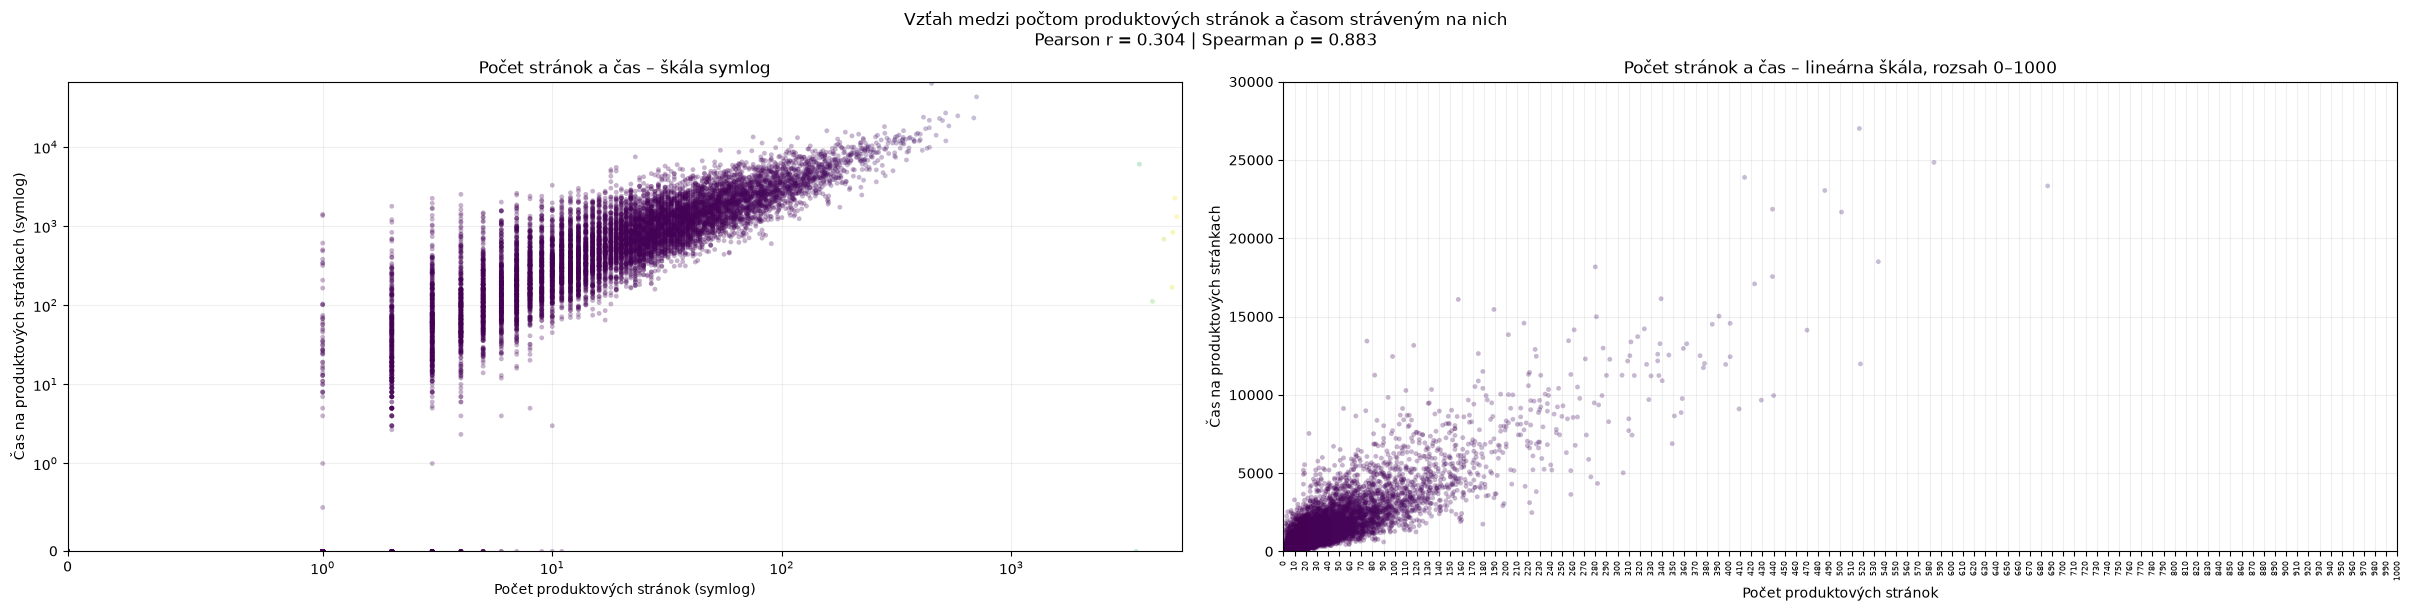

Počet session s časom nad 30 000: 2


,SessionID,ProductRelated,ProductRelated_Duration
0,S-108071,449.0,63973.52223
1,S-105152,705.0,43171.23338


In [27]:
product_pair = data_clean[
    ["ProductRelated", "ProductRelated_Duration"]
].dropna()

pearson_matrix = product_pair.corr(method="pearson")
pearson = pearson_matrix.iloc[0, 1]
spearman = product_pair.corr(method="spearman").iloc[0, 1]

print(
    f"Počet session: {len(product_pair)} | "
    f"Pearson r = {pearson:.3f} | Spearman ρ = {spearman:.3f}"
)

fig, axes = plt.subplots(
    1, 2, figsize=(24, 6), constrained_layout=True
)

for ax in axes[:2]:
    sns.scatterplot(
        data=product_pair,
        x="ProductRelated",
        y="ProductRelated_Duration",
        hue="ProductRelated",
        palette="viridis",
        hue_norm=(
            product_pair["ProductRelated"].min(),
            product_pair["ProductRelated"].max()
        ),
        legend=False,
        alpha=0.3,
        s=12,
        edgecolor="none",
        ax=ax,
    )
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)

# Prvý graf: obe osi v škále symlog, všetky hodnoty.
axes[0].set_xscale("symlog", linthresh=1)
axes[0].set_yscale("symlog", linthresh=1)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0)
axes[0].set(
    title="Počet stránok a čas – škála symlog",
    xlabel="Počet produktových stránok (symlog)",
    ylabel="Čas na produktových stránkach (symlog)",
)

# Druhý graf: lineárne osi, os x po 10 do 1000.
# Body s počtom stránok nad 1000 sú mimo zobrazeného rozsahu.
axes[1].set_xscale("linear")
axes[1].set_yscale("linear")
axes[1].set_xlim(0, 1000)
axes[1].set_ylim(0, 30_000)
axes[1].set_xticks(np.arange(0, 1001, 10))
axes[1].tick_params(axis="x", labelrotation=90, labelsize=6)
axes[1].set(
    title="Počet stránok a čas – lineárna škála, rozsah 0–1000",
    xlabel="Počet produktových stránok",
    ylabel="Čas na produktových stránkach",
)

# Tretí graf: korelácia vypočítaná zo všetkých pôvodných hodnôt.
# sns.heatmap(
#     pearson_matrix,
#     annot=True,
#     fmt=".3f",
#     cmap="viridis",
#     vmin=-1,
#     vmax=1,
#     square=True,
#     ax=axes[2],
# )
# axes[2].set_title(f"Pearsonova korelácia: r = {pearson:.3f}")

fig.suptitle(
    "Vzťah medzi počtom produktových stránok a časom stráveným na nich\n"
    f"Pearson r = {pearson:.3f} | Spearman ρ = {spearman:.3f}"
)
plt.show()

# Session s časom nad 30 000, bez ohľadu na počet stránok.
duration_outliers = data_clean.loc[
    data_clean["ProductRelated_Duration"] > 30_000,
    ["SessionID", "ProductRelated", "ProductRelated_Duration"]
].sort_values("ProductRelated_Duration", ascending=False)

print(f"Počet session s časom nad 30 000: {len(duration_outliers)}")

# Každý riadok predstavuje jednu session prekračujúcu limit.
display(duration_outliers.reset_index(drop=True))

Graf ukazuje, ze s rastucim poctom navstivenych produktovych stranok rastie aj cas straveny na nich. Pearsonova korelacia je 0.304, co naznacuje slabsiu linearnu zavislost. Spearmanova korelacia 0.883 ukazuje silny vztah, vyssiemu poctu stranok vacsinou pripada dlhsi cas, hoci tento rast nie je rovnomerny.

Graf so skalou `symlog` umoznuje ukazat extremne hodnoty a lepsie odhaluje rastuci trend. Linearny graf ukazuje, ze vacsina sessionov sa sustreduje pri nizsich poctoch stranok a kratsom case. 

Pri rovnakom pocte stranok sa cas medzi sessionami vyrazne lisi. Viditelne su aj extremne hodnoty s vysokym poctom stranok a pomerne kratkym casom, ktore mozu ovplyvnovat Pearsonovu korelaciu. Pocet produktovych stranok suvisi s casom navstevy, ale sam nestaci na jeho presny odhad.

# Classification

## data separation

In [19]:
X = data_clean.drop(columns=["SessionID", "Revenue"])
y = data_clean["Revenue"].copy()
print(f"X: {X.shape}, y: {y.shape}")

X: (11583, 16), y: (11583,)
